# Final 30×30 experiments

This notebook only loads the persisted CSV results. It does not import or rerun the optimizer. It creates one objective-versus-query figure and one samples-versus-minimum figure for each objective.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_experiment_directory():
    cwd = Path.cwd().resolve()
    if (cwd / 'data' / 'objective_vs_queries.csv').exists():
        return cwd
    candidate = cwd / 'experiments' / 'final_experiments'
    if (candidate / 'data' / 'objective_vs_queries.csv').exists():
        return candidate
    raise FileNotFoundError('Run run_query_experiment.py before plotting')


EXPERIMENT_DIR = find_experiment_directory()
DATA_DIR = EXPERIMENT_DIR / 'data'
FIGURE_DIR = EXPERIMENT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

query_results = pd.read_csv(DATA_DIR / 'objective_vs_queries.csv')
# sample_results = pd.read_csv(DATA_DIR / 'samples_vs_minimum.csv')

OBJECTIVES = ('ky_fan_regression', 'singular_value_sum')
EXPECTED_ALGORITHMS = {
    'adjoint_sensing_operator',
    'alternating_projections',
    'burer_monteiro_gradient_descent',
    'iterative_hard_thresholding',
    'pseudoinverse',
    'rangefinder',
    'spectral_iterative_hard_thresholding',
}

assert set(query_results.loc[query_results.status == 'success', 'algorithm']) == EXPECTED_ALGORITHMS
assert set(query_results.loc[query_results.status == 'success', 'objective']) == set(OBJECTIVES)
successful_query_runs = set(
    query_results.loc[query_results.status == 'success', ['algorithm', 'objective']]
    .itertuples(index=False, name=None)
)
unresolved_query_failures = query_results[query_results.status == 'failed'].apply(
    lambda row: (row.algorithm, row.objective) not in successful_query_runs, axis=1
)
assert not unresolved_query_failures.any()

print(f'Loaded {len(query_results):,} query-history rows')
# print(f'Loaded {len(sample_results):,} sample-sweep rows')
# display(sample_results.groupby(['objective', 'status']).size().rename('rows'))

Loaded 5,712 query-history rows


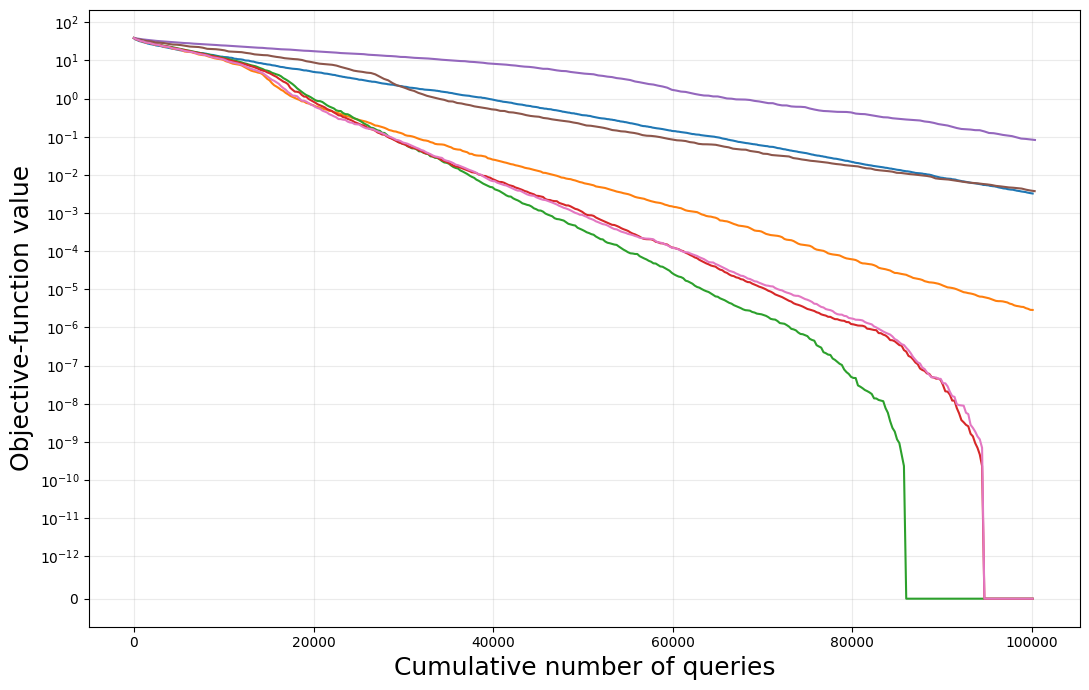

Saved /Users/danielmckenzie/Documents/Active_Research/Zeroth_Order_Optimization/ZORO-extensions-2024/ZOOM/experiments/final_experiments/figures/objective_vs_queries_ky_fan_regression.png


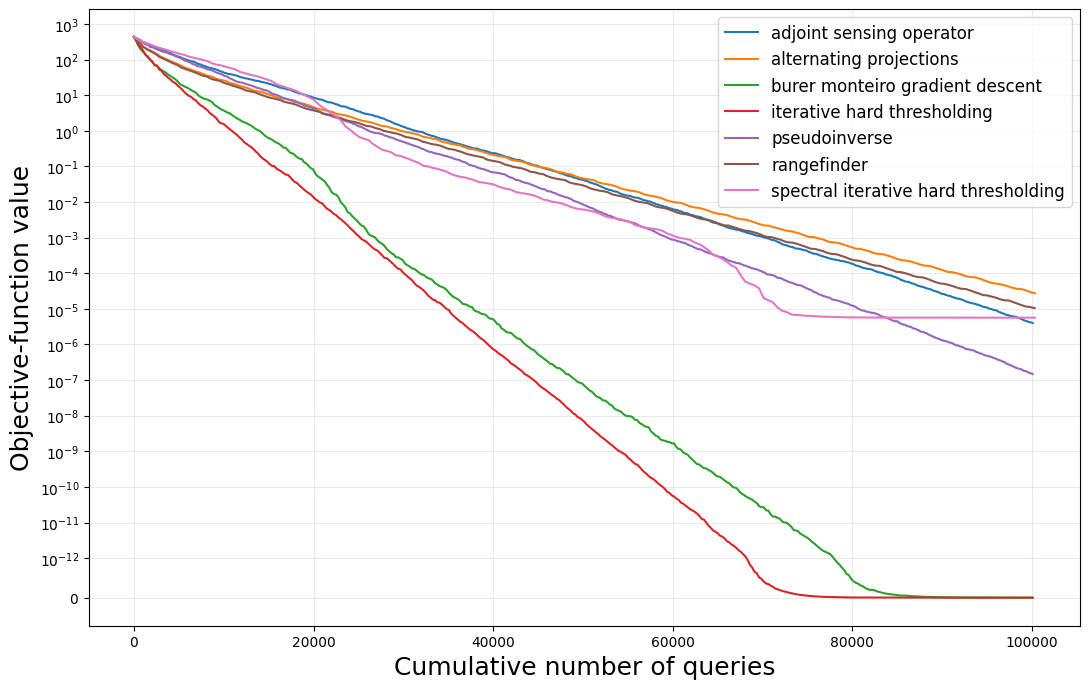

Saved /Users/danielmckenzie/Documents/Active_Research/Zeroth_Order_Optimization/ZORO-extensions-2024/ZOOM/experiments/final_experiments/figures/objective_vs_queries_singular_value_sum.png


In [4]:
# Experiment 1: objective value versus cumulative query count
for objective in OBJECTIVES:
    figure, axis = plt.subplots(figsize=(11, 7))
    objective_data = query_results[
        (query_results.objective == objective)
        & (query_results.status == 'success')
    ]

    for algorithm, run_data in objective_data.groupby('algorithm', sort=True):
        run_data = run_data.sort_values('queries')
        axis.plot(
            run_data.queries,
            run_data.objective_value,
            linewidth=1.5,
            label=algorithm.replace('_', ' '),
        )

    axis.set_xlabel('Cumulative number of queries', fontsize=18)
    axis.set_ylabel('Objective-function value', fontsize=18)
    axis.set_yscale('symlog', linthresh=1e-12)
    axis.grid(True, which='both', alpha=0.25)
    if objective == 'singular_value_sum':
        axis.legend(fontsize=12)
    figure.tight_layout()

    output_path = FIGURE_DIR / f'objective_vs_queries_{objective}.png'
    figure.savefig(output_path, dpi=180, bbox_inches='tight')
    plt.show()
    print(f'Saved {output_path}')

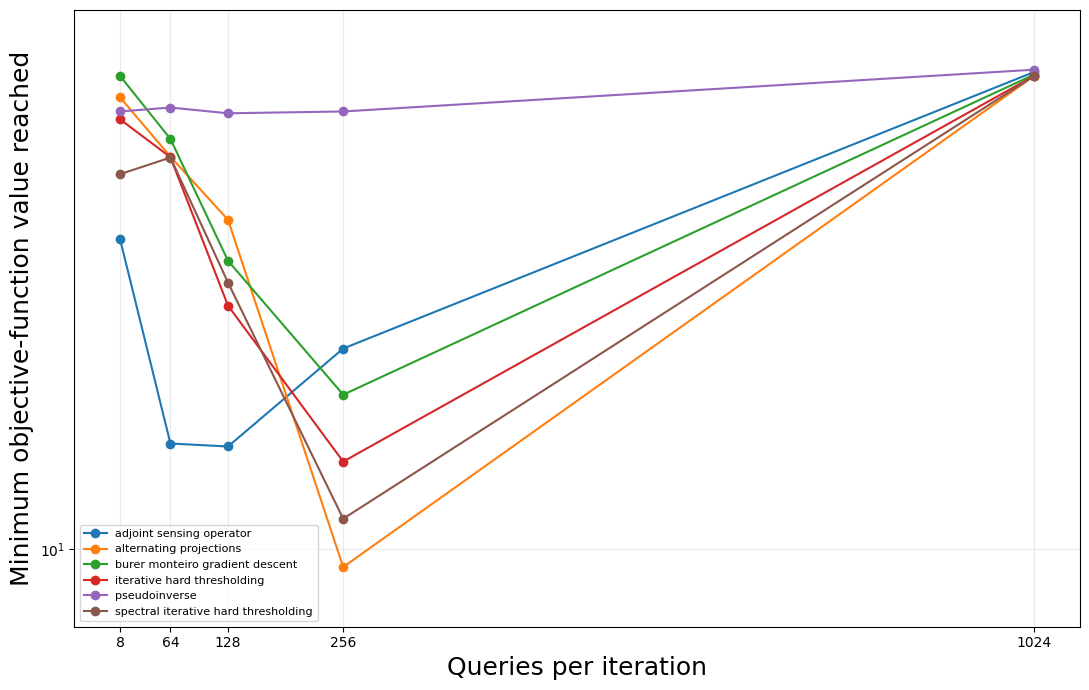

Saved /Users/danielmckenzie/Documents/Active_Research/Zeroth_Order_Optimization/ZORO-extensions-2024/ZOOM/experiments/final_experiments/figures_experimental/samples_vs_minimum_ky_fan_regression.png


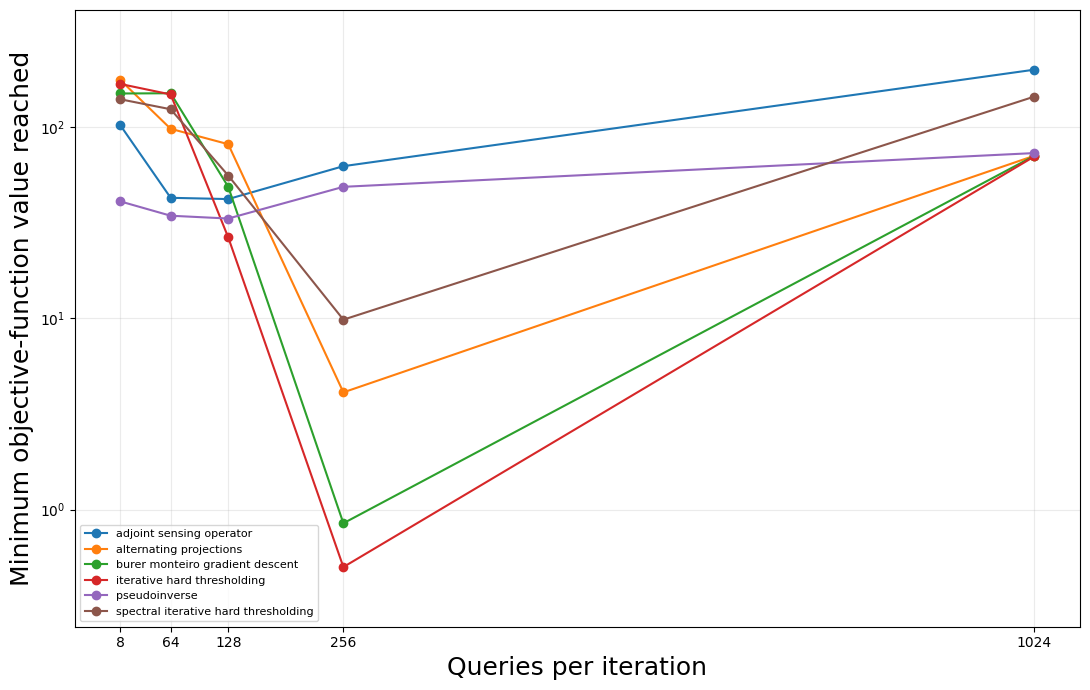

Saved /Users/danielmckenzie/Documents/Active_Research/Zeroth_Order_Optimization/ZORO-extensions-2024/ZOOM/experiments/final_experiments/figures_experimental/samples_vs_minimum_singular_value_sum.png


,algorithm,objective,error_message
50,rangefinder,ky_fan_regression,rangefinder does not use samps_per_iter
51,rangefinder,singular_value_sum,rangefinder does not use samps_per_iter


In [ ]:
# Experiment 2: samples per iteration versus minimum objective value
sample_results['samps_per_iter_numeric'] = pd.to_numeric(
    sample_results.samps_per_iter, errors='coerce'
)

for objective in OBJECTIVES:
    figure, axis = plt.subplots(figsize=(11, 7))
    objective_data = sample_results[
        (sample_results.objective == objective)
        & sample_results.status.isin(['success', 'failed'])
        & sample_results.minimum_objective_value.notna()
    ]

    for algorithm, run_data in objective_data.groupby('algorithm', sort=True):
        run_data = run_data.sort_values('samps_per_iter_numeric')
        axis.plot(
            run_data.samps_per_iter_numeric,
            run_data.minimum_objective_value,
            marker='o',
            linewidth=1.5,
            label=algorithm.replace('_', ' '),
        )

    axis.set_yscale('symlog', linthresh=1e-12)
    axis.margins(y=0.12)
    axis.set_xticks(sorted(objective_data.samps_per_iter_numeric.unique()))
    axis.set_xlabel('Queries per iteration', fontsize=18)
    axis.set_ylabel('Minimum objective-function value reached',fontsize=18)
    axis.grid(True, which='both', alpha=0.25)
    #axis.legend(fontsize=8)
    figure.tight_layout()

    output_path = FIGURE_DIR / f'samples_vs_minimum_{objective}.png'
    figure.savefig(output_path, dpi=180, bbox_inches='tight')
    plt.show()
    print(f'Saved {output_path}')

not_applicable = sample_results[sample_results.status == 'not_applicable'][
    ['algorithm', 'objective', 'error_message']
]
display(not_applicable)